In [1]:
import os
import sys

# This script can be run from the project root or from the notebooks directory.
# If we are in the notebooks directory, we need to add the project root to the path.
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(".."))


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from opt_library.core.centralized.first_order.adadelta.adadelta import Adadelta
from opt_library.core.centralized.first_order.adagrad.adagrad import Adagrad
from opt_library.core.centralized.first_order.adam.adam import Adam
from opt_library.core.centralized.first_order.gradient_descent.gradient_descent import (
    GradientDescent,
)
from opt_library.core.centralized.first_order.momentum.momentum import Momentum
from opt_library.core.centralized.first_order.nesterov.nesterov import Nesterov
from opt_library.core.centralized.first_order.rmsprop.rmsprop import RMSProp
from opt_library.core.common.base_problem import DifferentiableProblem
from opt_library.simulator.base_logger import ListLogger
from opt_library.simulator.base_stopping_condition import (
    IterationBudget,
)
from opt_library.simulator.problems import (
    Ackley,
    Beale,
    LinearRegressionProblem,
)


In [3]:
# ==============================================================================
# Helper Functions for Plotting
# ==============================================================================


def plot_convergence_paths(problem: DifferentiableProblem, logs: list, titles: list):
    """Plots the 2D convergence path of optimization algorithms."""
    if problem.dimension != 2:
        print("Cannot plot 2D path for non-2D problem.")
        return

    x_min, y_min = problem.min_point
    bounds = problem.bounds
    x_bounds = bounds[0]
    y_bounds = bounds[1]

    x = np.linspace(x_bounds[0], x_bounds[1], 400)
    y = np.linspace(y_bounds[0], y_bounds[1], 400)
    X, Y = np.meshgrid(x, y)
    problem.reset_fevals()
    Z = np.array(
        [problem._evaluate(np.array([x, y])) for x, y in zip(X.ravel(), Y.ravel())]
    ).reshape(X.shape)
    problem.reset_fevals()

    plt.figure(figsize=(12, 8))
    plt.contour(
        X,
        Y,
        Z,
        levels=np.logspace(0, 5, 35),
        norm=plt.cm.colors.LogNorm(),
        cmap=plt.cm.viridis,
    )
    plt.plot(x_min, y_min, "r*", markersize=15, label="Minimum")

    for log, title in zip(logs, titles):
        path = np.array([item["x"] for item in log])
        plt.plot(path[:, 0], path[:, 1], "o-", label=title, alpha=0.7)

    plt.title(f"Convergence Path on {problem.__class__.__name__}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_value_difference(
    logs: list,
    titles: list,
    problem: DifferentiableProblem,
    xlim=None,
    ylim=None,
):
    """Plots f(x_k) - f(x*) in log scale."""
    min_value = problem.min_value
    plt.figure(figsize=(10, 6))
    for log, title in zip(logs, titles):
        fevals = [item["fevals"] for item in log]
        values = [item["value"] - min_value for item in log]
        plt.plot(fevals, values, label=title)
    plt.xlabel("Number of Oracle Calls")
    plt.ylabel("f(x_k) - f(x*)")
    plt.title(f"Value Difference on {problem.__class__.__name__} (Log Scale)")
    plt.yscale("log")
    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_gradient_norm(
    logs: list,
    titles: list,
    problem: DifferentiableProblem,
    xlim=None,
    ylim=None,
):
    """Plot gradient norm of algorithms."""
    plt.figure(figsize=(10, 6))
    for log, title in zip(logs, titles):
        fevals = [item["fevals"] for item in log]
        norms = [np.linalg.norm(problem.gradient(item["x"])) for item in log]
        plt.plot(fevals, norms, label=title)
    plt.xlabel("Number of Oracle Calls")
    plt.ylabel("Gradient Norm")
    plt.title(f"Gradient Norm on {problem.__class__.__name__} (Log Scale)")
    plt.yscale("log")
    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.show()


def run_and_plot_comparison(
    problem: DifferentiableProblem,
    algorithms: list,
    starting_point: np.ndarray,
    budget: int,
):
    """Runs algorithms on a problem and plots all comparison graphs."""
    print("=" * 80)
    print(f"Running comparison on {problem.__class__.__name__}")
    print("=" * 80)

    logs = []
    titles = []
    max_fevals = 0

    for alg_class, params, name in algorithms:
        problem.reset_fevals()
        alg = alg_class(**params)
        logger = ListLogger()
        print(f"Running {name}...")
        alg.fit(
            problem=problem,
            starting_point=starting_point.copy(),
            stopping_condition=IterationBudget(budget),
            logger=logger,
        )
        log = logger.get_log()
        logs.append(log)
        titles.append(name)
        if log:
            max_fevals = max(max_fevals, log[-1]["fevals"])

    plot_gradient_norm(logs, titles, problem, xlim=(0, max_fevals))
    plot_value_difference(logs, titles, problem, xlim=(0, max_fevals))
    if problem.dimension == 2:
        plot_convergence_paths(problem, logs, titles)


# ==============================================================================
# Test Problems
# ==============================================================================



In [4]:
# --- Problem 1: Rosenbrock (already in a file, but for notebooks it's fine) ---
class RosenbrockProblem(DifferentiableProblem):
    def __init__(self, dim=2):
        super().__init__()
        self._dimension = dim
        self.min_value = 0.0
        self.min_point = np.ones(dim)
        self.bounds = [(-2, 2)] * dim

    @property
    def dimension(self) -> int:
        return self._dimension

    def _evaluate(self, x: np.ndarray) -> float:
        return float(sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1 - x[:-1]) ** 2.0))

    def gradient(self, x: np.ndarray) -> np.ndarray:
        xm = x[1:-1]
        xm_m1 = x[:-2]
        xm_p1 = x[2:]
        grad = np.zeros_like(x)
        grad[1:-1] = 200 * (xm - xm_m1**2) - 400 * (xm_p1 - xm**2) * xm - 2 * (1 - xm)
        grad[0] = -400 * x[0] * (x[1] - x[0] ** 2) - 2 * (1 - x[0])
        grad[-1] = 200 * (x[-1] - x[-2] ** 2)
        return grad


# --- Algorithms to Compare ---
algorithms_to_compare = [
    (GradientDescent, {"learning_rate": 0.001}, "GD"),
    (Momentum, {"learning_rate": 0.001, "gamma": 0.9}, "Momentum"),
    (Nesterov, {"learning_rate": 0.001, "gamma": 0.9}, "Nesterov"),
    (Adagrad, {"learning_rate": 0.1}, "Adagrad"),
    (RMSProp, {"learning_rate": 0.01, "beta": 0.9}, "RMSProp"),
    (Adadelta, {"rho": 0.95, "epsilon": 1e-6}, "Adadelta"),
    (Adam, {"learning_rate": 0.01, "beta1": 0.9, "beta2": 0.999}, "Adam"),
]


Running comparison on RosenbrockProblem
Running GD...
Running Momentum...
Running Nesterov...
Running Adagrad...
Running RMSProp...
Running Adadelta...
Running Adam...


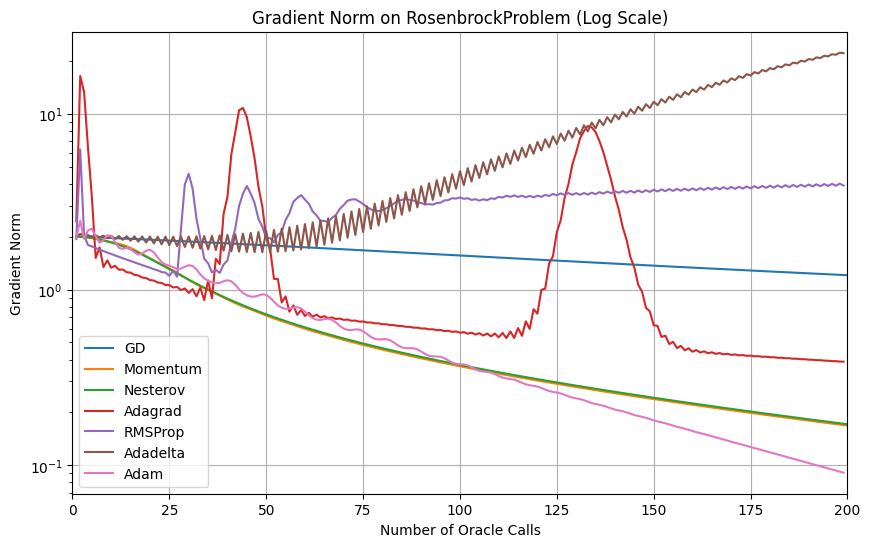

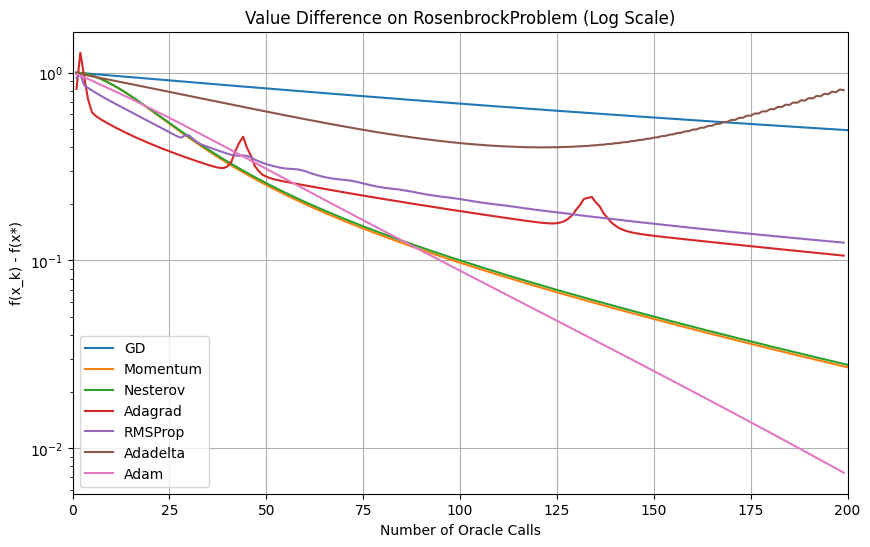

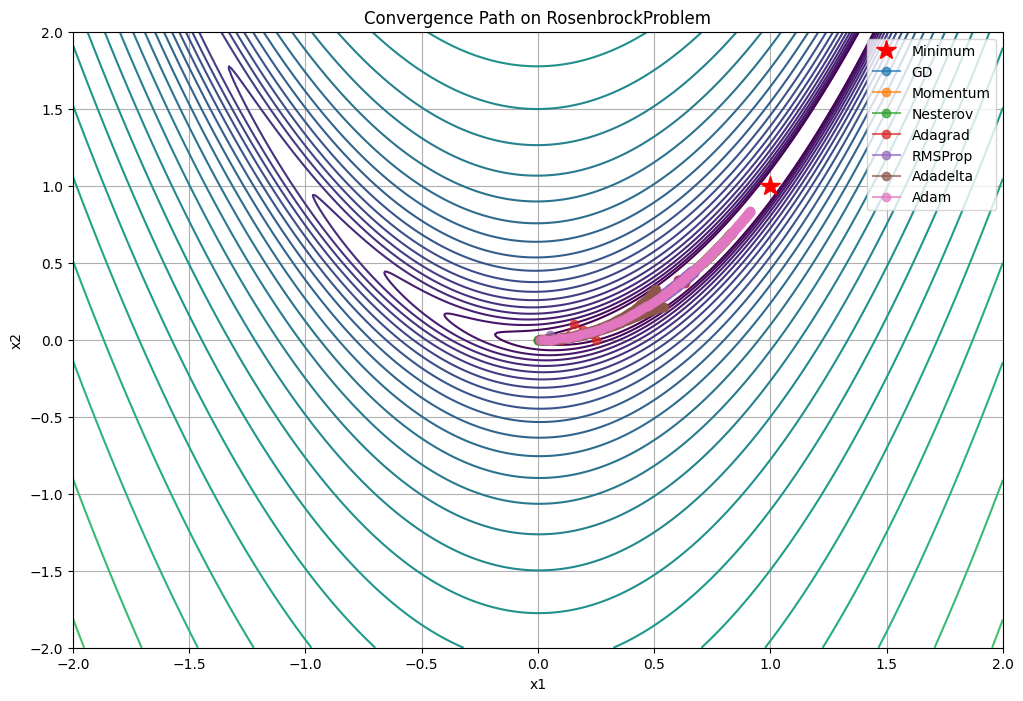

In [5]:
# --- Run on Rosenbrock ---
rosenbrock = RosenbrockProblem(dim=2)
run_and_plot_comparison(
    problem=rosenbrock,
    algorithms=algorithms_to_compare,
    starting_point=np.array([0.0, 0.0]),
    budget=200,
)


Running comparison on Beale
Running GD...
Running Momentum...
Running Nesterov...
Running Adagrad...
Running RMSProp...
Running Adadelta...
Running Adam...


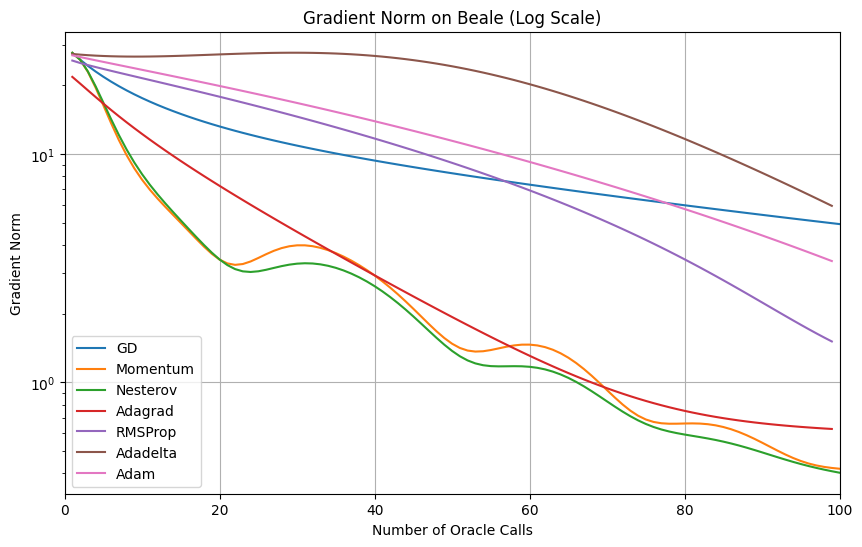

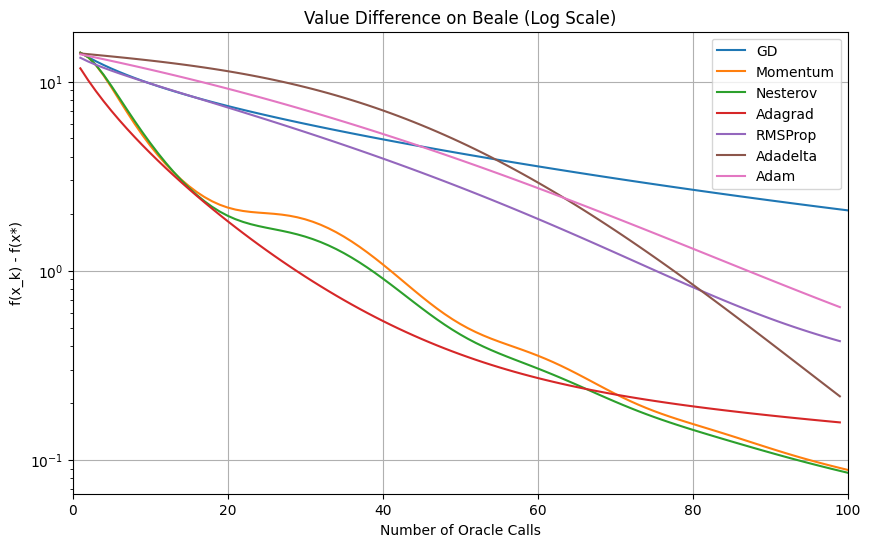

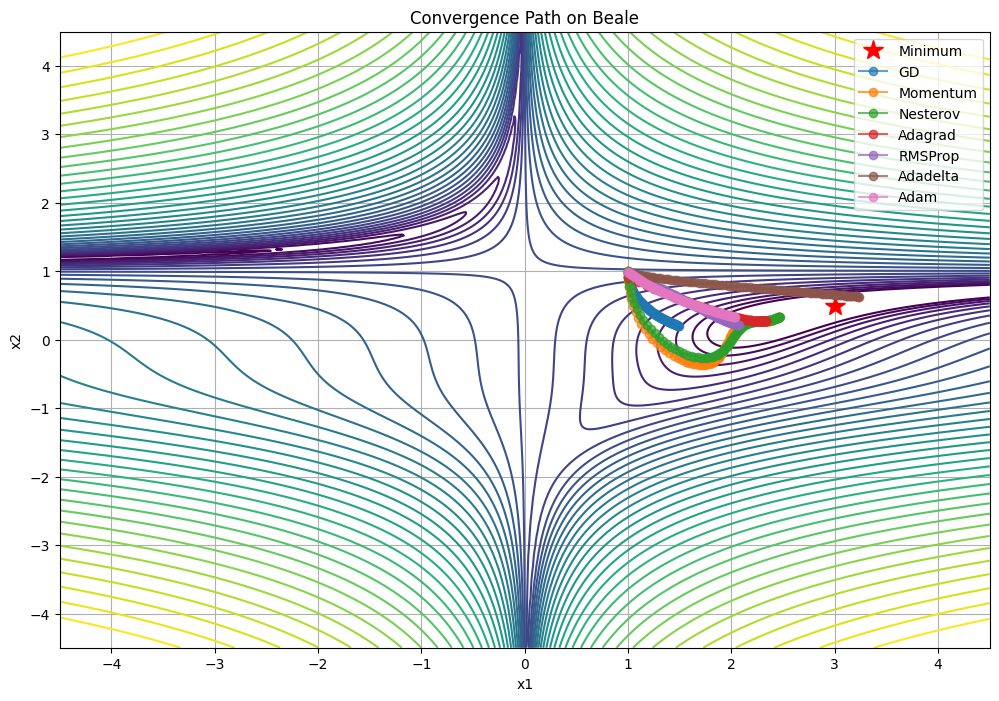

In [6]:
# --- Run on Beale ---
beale = Beale()
run_and_plot_comparison(
    problem=beale,
    algorithms=algorithms_to_compare,
    starting_point=np.array([1.0, 1.0]),
    budget=100,
)


Running comparison on Ackley
Running GD...
Running Momentum...
Running Nesterov...
Running Adagrad...
Running RMSProp...
Running Adadelta...
Running Adam...


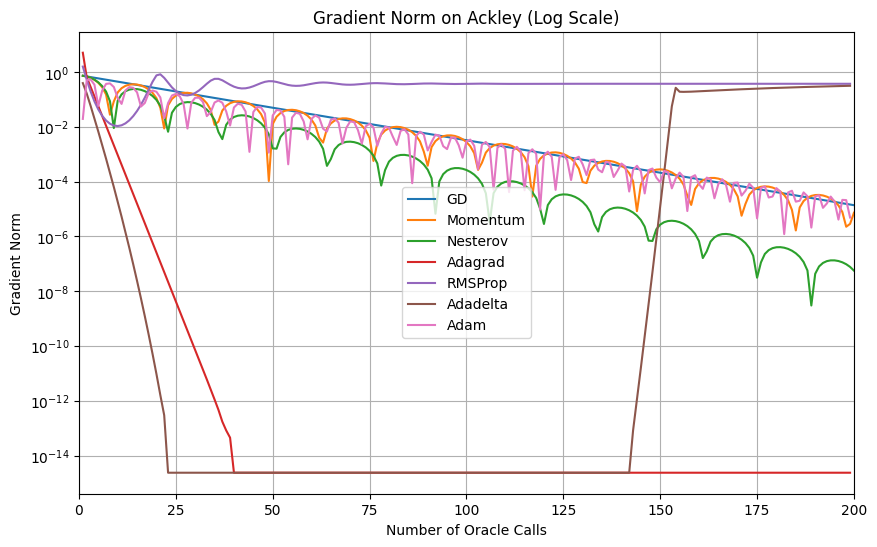

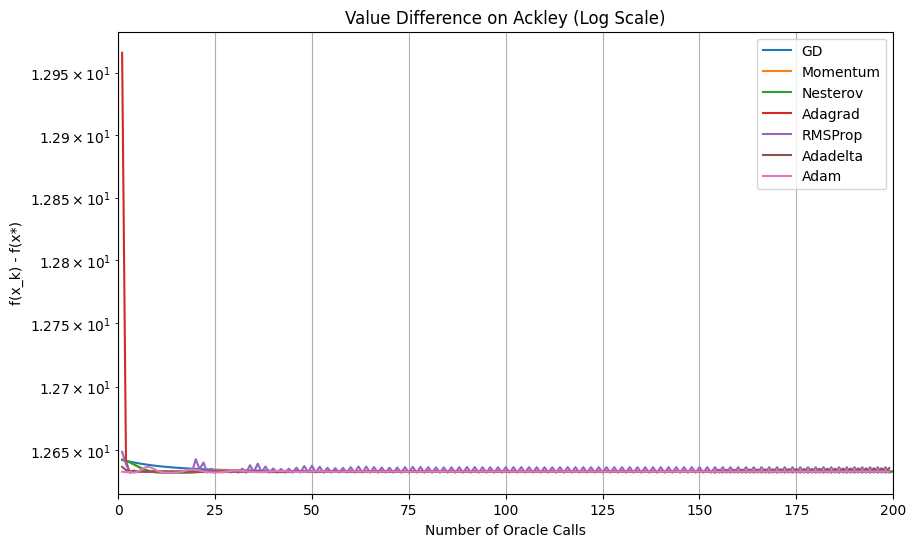

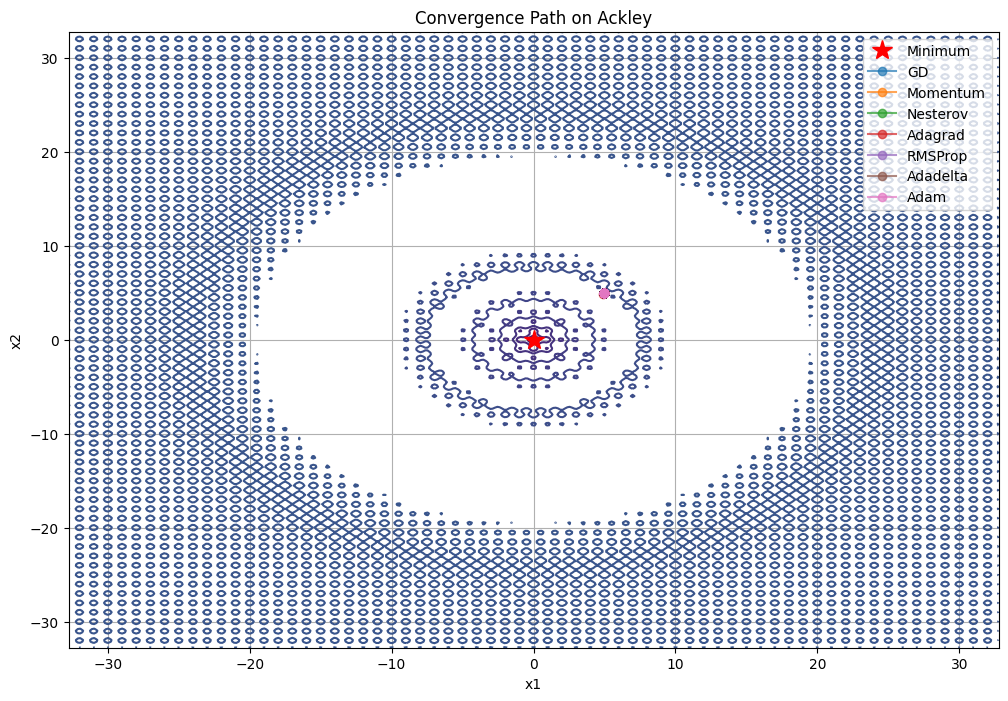

In [7]:
# --- Run on Ackley ---
ackley = Ackley(dim=2)
run_and_plot_comparison(
    problem=ackley,
    algorithms=algorithms_to_compare,
    starting_point=np.array([5.0, 5.0]),
    budget=200,
)


Running comparison on LinearRegressionProblem
Running GD...
Running Momentum...
Running Nesterov...
Running Adagrad...
Running RMSProp...
Running Adadelta...
Running Adam...


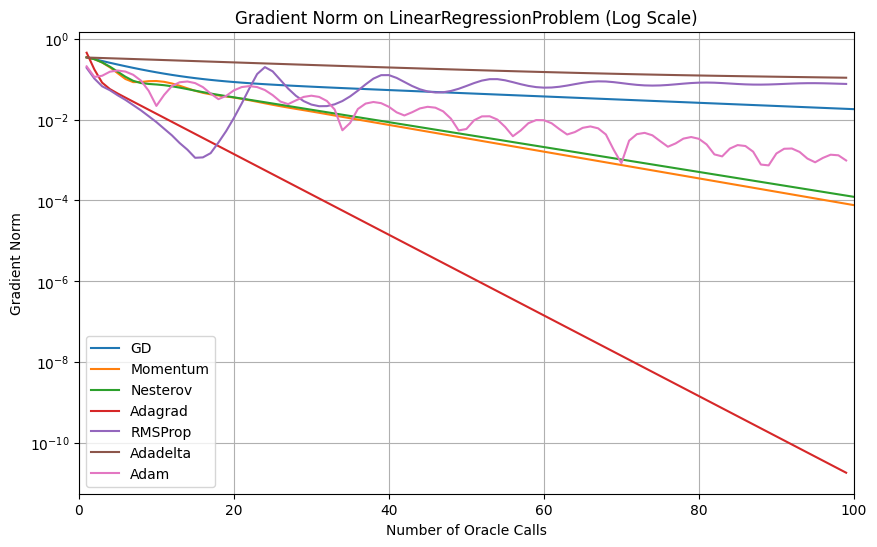

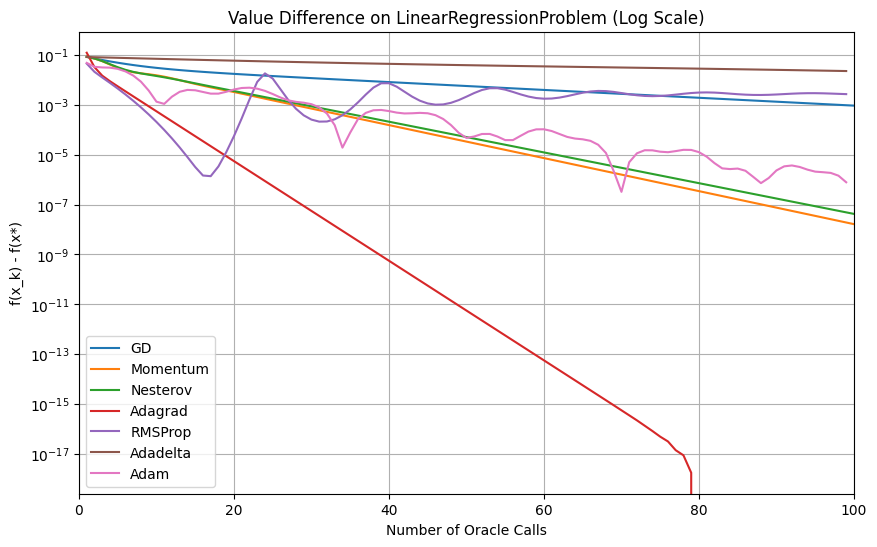

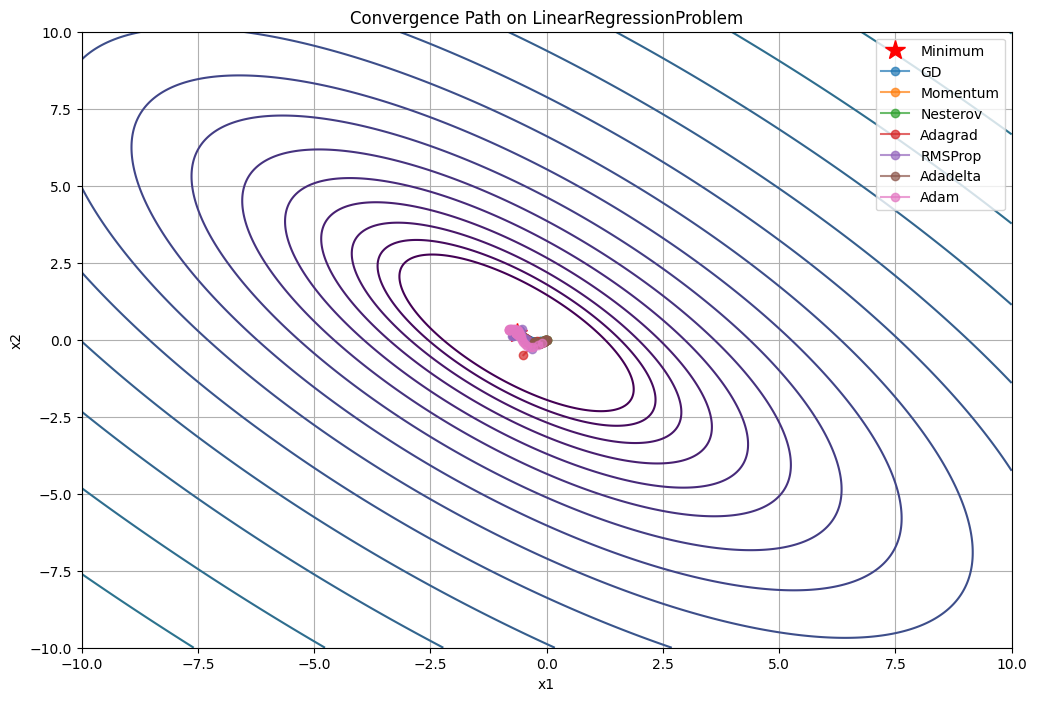


Comparison script finished.


In [8]:
# --- Run on Linear Regression ---
np.random.seed(42)
n_samples, n_features = 100, 2  # 2 features for 2D plot
X = np.random.rand(n_samples, n_features)
true_w = np.random.randn(n_features)
y = X @ true_w + 0.1 * np.random.randn(n_samples)

lin_reg_problem = LinearRegressionProblem(X, y)

# To get min_value, we solve it analytically
# This is a convex problem, so GD will find the minimum
gd_solver = GradientDescent(learning_rate=0.1)
final_w, min_val = gd_solver.fit(
    problem=lin_reg_problem,
    starting_point=np.zeros(n_features),
    stopping_condition=IterationBudget(1000),
)
lin_reg_problem.min_value = min_val
lin_reg_problem.min_point = final_w
lin_reg_problem.bounds = [(-10, 10)] * n_features


lr_algorithms = [
    (GradientDescent, {"learning_rate": 0.1}, "GD"),
    (Momentum, {"learning_rate": 0.1, "gamma": 0.7}, "Momentum"),
    (Nesterov, {"learning_rate": 0.1, "gamma": 0.7}, "Nesterov"),
    (Adagrad, {"learning_rate": 0.5}, "Adagrad"),
    (RMSProp, {"learning_rate": 0.1, "beta": 0.9}, "RMSProp"),
    (Adadelta, {"rho": 0.9, "epsilon": 1e-6}, "Adadelta"),
    (Adam, {"learning_rate": 0.1, "beta1": 0.9, "beta2": 0.999}, "Adam"),
]

run_and_plot_comparison(
    problem=lin_reg_problem,
    algorithms=lr_algorithms,
    starting_point=np.zeros(n_features),
    budget=100,
)

print("\nComparison script finished.")
